In [1]:
import pandas as pd

df = pd.read_csv("netflix_titles.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [2]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 8807
Number of columns: 12


In [3]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [5]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [6]:
df["type"].value_counts()

,count
type,
Movie,6131
TV Show,2676


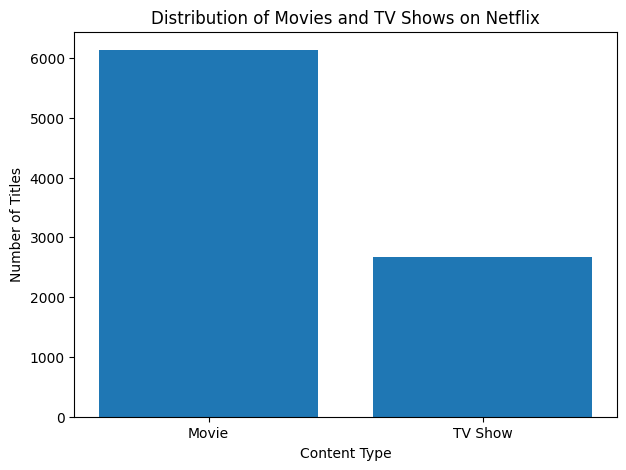

In [7]:
import matplotlib.pyplot as plt

type_counts = df["type"].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(type_counts.index, type_counts.values)
plt.title("Distribution of Movies and TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.show()

In [10]:
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

In [11]:
df["date_added"].dtype

dtype('<M8[ns]')

In [12]:
df["year_added"] = df["date_added"].dt.year

year_counts = df["year_added"].value_counts().sort_index()

year_counts

,count
year_added,
2008.0,2
2009.0,2
2010.0,1
2011.0,13
2012.0,3
2013.0,10
2014.0,23
2015.0,73
2016.0,418


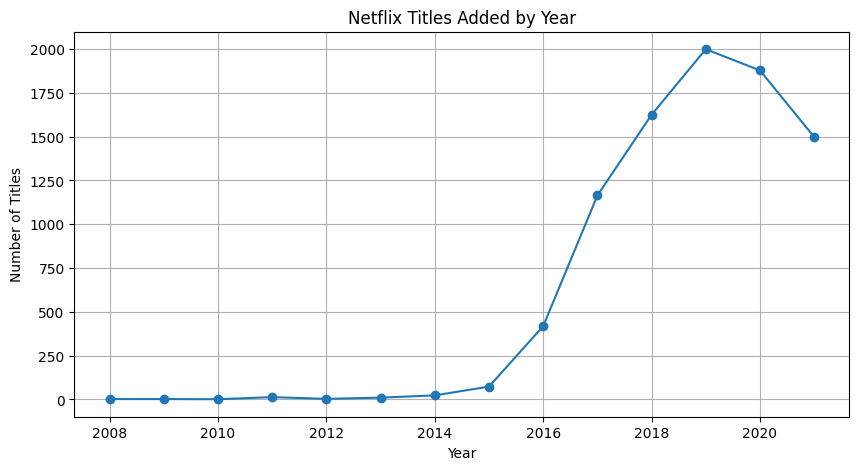

In [13]:
plt.figure(figsize=(10, 5))

plt.plot(year_counts.index, year_counts.values, marker="o")

plt.title("Netflix Titles Added by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.grid(True)

plt.show()

In [14]:
year_counts

,count
year_added,
2008.0,2
2009.0,2
2010.0,1
2011.0,13
2012.0,3
2013.0,10
2014.0,23
2015.0,73
2016.0,418


In [15]:
df["country"].value_counts().head(10)

,count
country,
United States,2818
India,972
United Kingdom,419
Japan,245
South Korea,199
Canada,181
Spain,145
France,124
Mexico,110


In [16]:
country_data = df["country"].dropna().str.split(", ")

country_counts = country_data.explode().value_counts()

country_counts.head(10)

,count
country,
United States,3689
India,1046
United Kingdom,804
Canada,445
France,393
Japan,318
Spain,232
South Korea,231
Germany,226


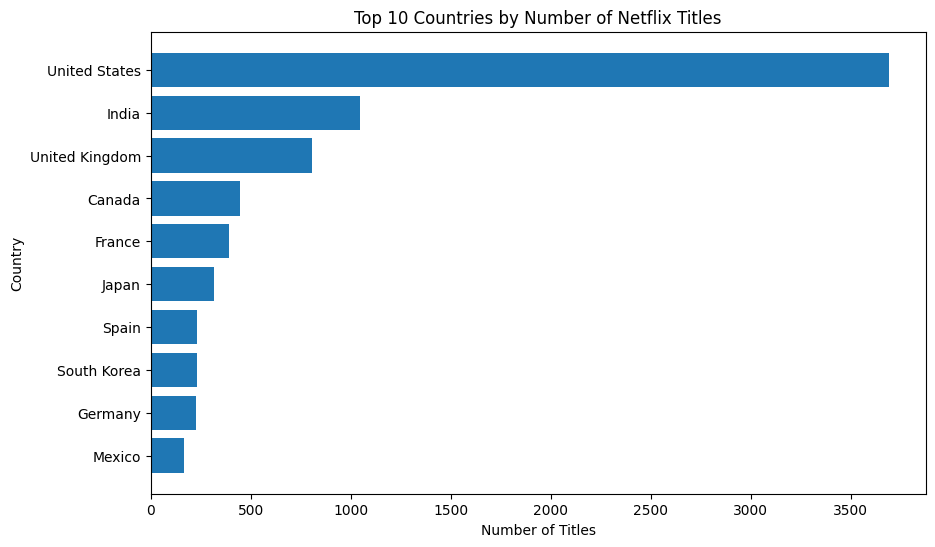

In [17]:
top_countries = country_counts.head(10)

plt.figure(figsize=(10, 6))

plt.barh(top_countries.index[::-1], top_countries.values[::-1])

plt.title("Top 10 Countries by Number of Netflix Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.show()

In [18]:
rating_counts = df["rating"].value_counts()

rating_counts

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


In [19]:
df[df["rating"].isin(["74 min", "84 min", "66 min"])]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,2017-04-04,2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi...",2017.0
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,2016-09-16,2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...,2016.0
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,2016-08-15,2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...,2016.0


In [21]:
# Fix incorrect values in the rating column

wrong_rating_values = ["74 min", "84 min", "66 min"]

df.loc[df["rating"].isin(wrong_rating_values), "duration"] = df.loc[
    df["rating"].isin(wrong_rating_values), "rating"
]

df.loc[df["rating"].isin(wrong_rating_values), "rating"] = pd.NA

In [22]:
df[df["title"].str.contains("Louis C.K.", na=False)][
    ["title", "rating", "duration"]
]

,title,rating,duration
5541,Louis C.K. 2017,<NA>,74 min
5794,Louis C.K.: Hilarious,<NA>,84 min
5813,Louis C.K.: Live at the Comedy Store,<NA>,66 min


In [23]:
rating_counts = df["rating"].value_counts()

rating_counts

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


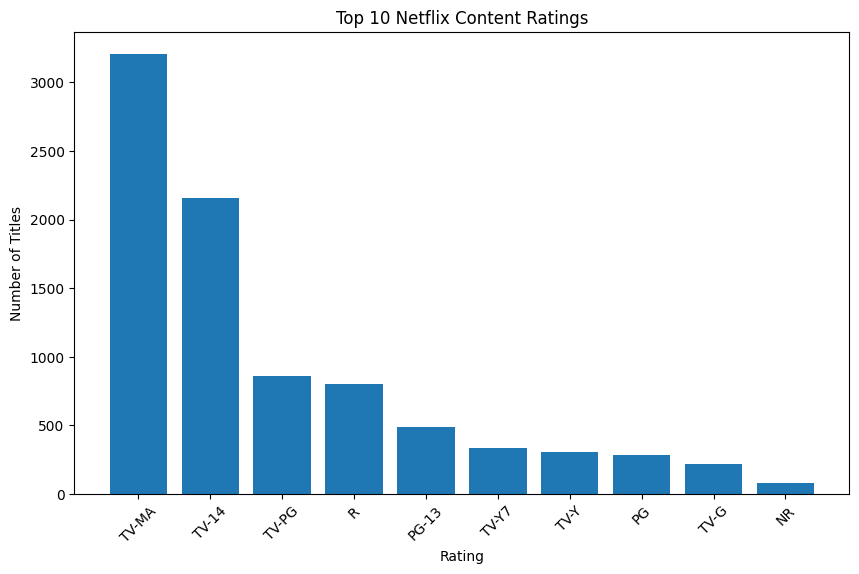

In [24]:
top_ratings = rating_counts.head(10)

plt.figure(figsize=(10, 6))

plt.bar(top_ratings.index, top_ratings.values)

plt.title("Top 10 Netflix Content Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)
plt.show()

In [25]:
genre_data = df["listed_in"].dropna().str.split(", ")

genre_counts = genre_data.explode().value_counts()

genre_counts.head(15)

,count
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1351
Documentaries,869
Action & Adventure,859
TV Dramas,763
Independent Movies,756
Children & Family Movies,641


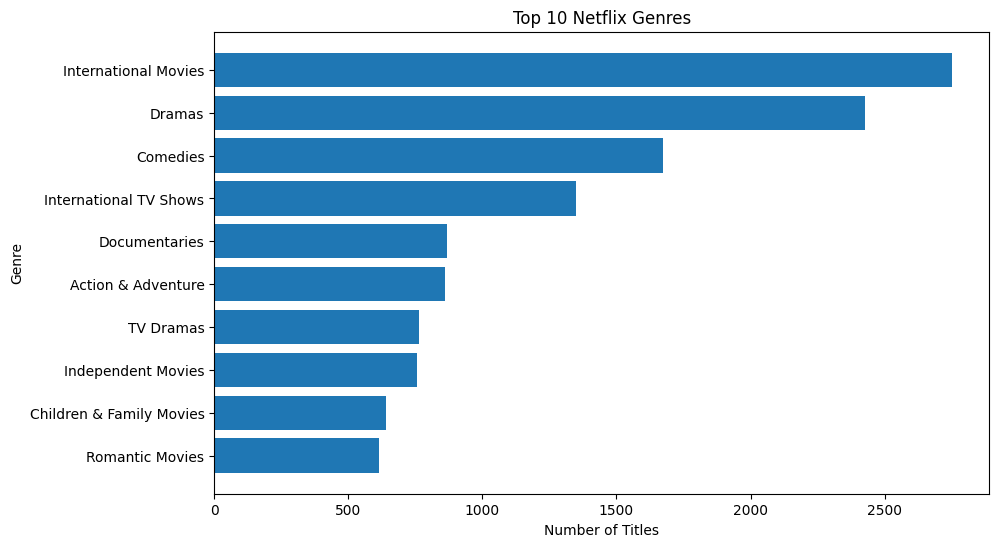

In [26]:
top_genres = genre_counts.head(10)

plt.figure(figsize=(10, 6))

plt.barh(top_genres.index[::-1], top_genres.values[::-1])

plt.title("Top 10 Netflix Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.show()

In [27]:
release_year_counts = df["release_year"].value_counts().sort_index()

release_year_counts.tail(20)

,count
release_year,
2002,51
2003,61
2004,64
2005,80
2006,96
2007,88
2008,136
2009,152
2010,194


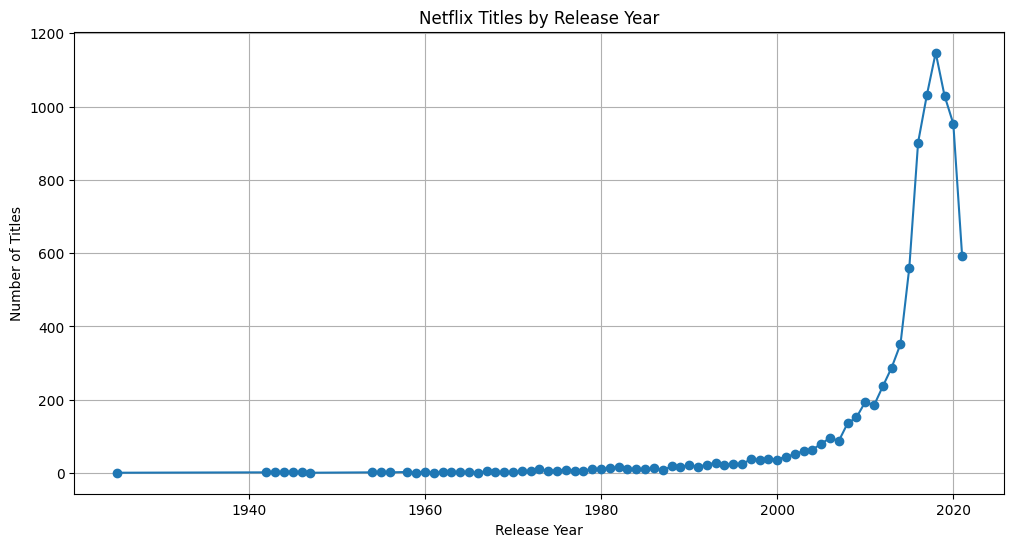

In [28]:
plt.figure(figsize=(12, 6))

plt.plot(
    release_year_counts.index,
    release_year_counts.values,
    marker="o"
)

plt.title("Netflix Titles by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.grid(True)
plt.show()

In [29]:
df["duration"].value_counts().head(20)

,count
duration,
1 Season,1793
2 Seasons,425
3 Seasons,199
90 min,152
97 min,146
94 min,146
93 min,146
91 min,144
95 min,137


In [30]:
df["seasons"] = df["duration"].str.extract(r"(\d+)").astype(float)

df[["type", "duration", "seasons"]].head(10)

,type,duration,seasons
0,Movie,90 min,90.0
1,TV Show,2 Seasons,2.0
2,TV Show,1 Season,1.0
3,TV Show,1 Season,1.0
4,TV Show,2 Seasons,2.0
5,TV Show,1 Season,1.0
6,Movie,91 min,91.0
7,Movie,125 min,125.0
8,TV Show,9 Seasons,9.0
9,Movie,104 min,104.0


In [31]:
tv_shows = df[df["type"] == "TV Show"].copy()

tv_shows["seasons"] = tv_shows["duration"].str.extract(r"(\d+)").astype(float)

tv_shows[["title", "duration", "seasons"]].head(10)

,title,duration,seasons
1,Blood & Water,2 Seasons,2.0
2,Ganglands,1 Season,1.0
3,Jailbirds New Orleans,1 Season,1.0
4,Kota Factory,2 Seasons,2.0
5,Midnight Mass,1 Season,1.0
8,The Great British Baking Show,9 Seasons,9.0
10,"Vendetta: Truth, Lies and The Mafia",1 Season,1.0
11,Bangkok Breaking,1 Season,1.0
14,Crime Stories: India Detectives,1 Season,1.0
15,Dear White People,4 Seasons,4.0


In [32]:
tv_shows["seasons"].value_counts().sort_index()

,count
seasons,
1.0,1793
2.0,425
3.0,199
4.0,95
5.0,65
6.0,33
7.0,23
8.0,17
9.0,9


In [33]:
correlation = tv_shows[["release_year", "seasons"]].corr()

correlation

,release_year,seasons
release_year,1.000000,-0.090194
seasons,-0.090194,1.000000


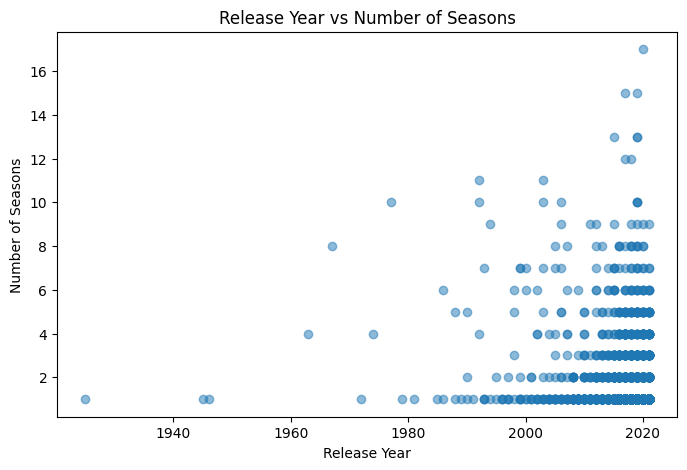

In [34]:
plt.figure(figsize=(8, 5))

plt.scatter(
    tv_shows["release_year"],
    tv_shows["seasons"],
    alpha=0.5
)

plt.title("Release Year vs Number of Seasons")
plt.xlabel("Release Year")
plt.ylabel("Number of Seasons")

plt.show()

In [35]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,98
release_year,0
rating,7
duration,0


In [36]:
df.shape

(8807, 14)

In [37]:
df.to_csv("netflix_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
